In [72]:
# Analysing data of Markkanen cloud multiband measurements


In [73]:
%matplotlib inline
import numpy as np
from uncertainties import ufloat
from uncertainties import umath
import matplotlib.pyplot as plt
from scipy import optimize, interpolate
from scipy.special import erf
from scipy.optimize import minimize
import scipy.integrate as integrate
from astropy import stats
import pickle
import stand_pol
from collections import OrderedDict

In [74]:
class star:
    def __init__(self ,PD, PDerr, PA, PAerr):
        self.PD    = PD        # in %
        self.PDerr = PDerr
        self.PA    = PA        # in deg
        self.PAerr = PAerr

STANDARDS = stand_pol.STANDARDS

In [75]:
class Obs():
    def __init__(self,name,JD,q,qerr,u,uerr,x=0.0,y=0.0):
        self.name = name
        self.JD   = JD
        self.q    = ufloat(q,qerr)
        self.u    = ufloat(u,uerr)
        self.x    = x
        self.y    = y

    def getP(self):
        return umath.sqrt(self.q ** 2 + self.u ** 2)

    def getPA(self):
        PAval = 0.5*umath.atan2(self.u,self.q)
        PAunc = self.getSigma(self.getP().n,self.getP().s)
        return ufloat(np.degrees(PAval.n),np.degrees(PAunc))
    
    def correctInst(self,q_inst,u_inst):
        self.q = self.q - q_inst
        self.u = self.u - u_inst
    
    def correctRot(self,dPA):
        THETA = umath.radians(dPA)
        Qnew = self.q * umath.cos(2*THETA) - self.u * umath.sin(2*THETA)
        Unew = self.q * umath.sin(2*THETA) + self.u * umath.cos(2*THETA)
        self.q = Qnew
        self.u = Unew
        
    def EVPA_pdf(self,theta,P0):
        """
        EVPA measurements are also non-Gaussian and defined by the following
        probability density (Naghizadeh-Khouei & Clarke 1993):
        """
        g = 1/np.sqrt(np.pi)
        ita0 = float(P0)/np.sqrt(2) * np.cos(2 * theta)
        g = g * (g + ita0 * np.exp(ita0**2) * (1 + erf(ita0)))
        g = g * np.exp(-(float(P0)**2)/2)
        return g
    
    def int_eq(self,sigma,snr):
        """ This is the integral of EVPA probability density from -sigma to sigma """
        integ = integrate.quad(lambda x: self.EVPA_pdf(x,snr),-sigma,sigma)
        return abs(integ[0] - 0.68268949)
    
    def getSigma(self,pd,pd_err):
        snr = pd/pd_err
        if snr > 20:
            # it is a good approximation even for snr = 5
            return 0.5*1.0/float(snr)

        if snr < np.sqrt(2.0):
            pd = 0.0
        else:
            pd = np.sqrt(pd**2 - pd_err**2)

        snr = pd/pd_err

        res = minimize(self.int_eq, [np.pi/50], args=(snr,), method='Nelder-Mead', tol=1e-5) # np.pi/50 = 3.6 deg - just a reasonable guess
        if res.status != 0:
            print('Something is wrong with the EVPA uncertainty calculation:\n')
            return np.nan

        return res.x[0]

class Stand():
    def __init__(self, st):
        self.name = st
        stand = stand_pol.STANDARDS[self.name]
        self.PD    = ufloat(stand.PD/100., stand.PDerr/100.)
        self.PA    = ufloat(stand.PA, stand.PAerr)
        self.calcQU()

    def calcQU(self):
        self.q = self.PD * umath.cos( 2 * umath.radians(self.PA) )
        self.u = self.PD * umath.sin( 2 * umath.radians(self.PA) )

Raw processed data (no model):

In [76]:
# 2459713
o1 = Obs("BD+28.4211", 2459713.57780, 0.00335,  0.00047,  0.00063,  0.00041, 1030.6, 1030.9)
o2 = Obs("BD+32.3739", 2459713.56119, 0.00581,  0.00048,  0.00070,  0.00052, 1027.9, 1028.2)
o3 = Obs("BD+33.2642", 2459713.27583, 0.00046,  0.00067,  0.00122,  0.00066, 1029.9, 1035.1)
o4 = Obs("BD+40.2704", 2459713.26807, 0.00152,  0.00060,  0.00215,  0.00039, 1031.2, 1031.5)
o5 = Obs("HD154892", 2459713.39168, 0.00560,  0.00027,  0.00156,  0.00065, 1029.5, 1023.1)
o6 = Obs("HD154892", 2459713.42859, 0.00384,  0.00059,  0.00079,  0.00046, 1033.3, 1029.0)

# 2459714
o7 = Obs("BD+28.4211", 2459714.59896, 0.00476,  0.00053,  0.00044,  0.00031, 1028.6, 1031.4)
o8 = Obs("BD+33.2642", 2459714.28425, 0.00527,  0.00080,  0.00032,  0.00080, 1027.2, 1029.8)
o9 = Obs("BD+40.2704", 2459714.26984, 0.00213,  0.00054,  0.00217,  0.00031, 1034.2, 1034.6)
o10 = Obs("HD154892", 2459714.41214, 0.00486,  0.00051,  0.00105,  0.00068, 1028.0, 1028.4)

# 2459715
o11 = Obs("BD+32.3739", 2459715.59975, 0.00120,  0.00075,  0.00078,  0.00050, 1031.3, 1032.4)
o12 = Obs("BD+33.2642", 2459715.29410, 0.00140,  0.00061,  0.00051,  0.00078, 1029.4, 1031.5)
o13 = Obs("BD+40.2704", 2459715.25960, 0.00615,  0.00043,  0.00049,  0.00062, 1027.4, 1029.0)
o14 = Obs("HD154892", 2459715.47258, 0.00340,  0.00070,  0.00117,  0.00035, 1033.2, 1032.2)
o15 = Obs("HD183143", 2459715.56033, 0.06345,  0.00030, -0.00473,  0.00025, 1031.5, 1031.8) # high P

# 2459716
o16 = Obs("BD+33.2642", 2459716.39994, 0.00257,  0.00073,  0.00213,  0.00068, 1030.7, 1031.0)
o17 = Obs("BD+33.2642", 2459716.50410, 0.00574,  0.00072, -0.00146,  0.00032, 1029.0, 1027.8)
o18 = Obs("BD+40.2704", 2459716.26929, 0.00299,  0.00053,  0.00288,  0.00030, 1032.7, 1029.9)
o19 = Obs("CygOB2_14", 2459716.47706, -0.02721,  0.00084,  0.00444,  0.00087, 1028.7, 1025.3) # high P
o20 = Obs("HD183143", 2459716.57581, 0.06604,  0.00059, -0.00395,  0.00076, 1030.2, 1022.5) # high P
o21 = Obs("VICyg12", 2459716.56921, -0.03663,  0.00047, -0.06630,  0.00016, 1030.1, 1027.5) # high P

# 2459717
o22 = Obs("BD+32.3739", 2459717.58861, 0.00288,  0.00047,  0.00137,  0.00089, 1028.3, 1029.5)
o23 = Obs("BD+33.2642", 2459717.46705, 0.00619,  0.00112,  0.00088,  0.00061, 1027.4, 1026.5)
o24 = Obs("BD+33.2642", 2459717.51533, 0.00550,  0.00061,  0.00077,  0.00099, 1028.7, 1025.8)
o25 = Obs("BD+40.2704", 2459717.40397, 0.00125,  0.00038,  0.00221,  0.00030, 1033.6, 1028.0)
o26 = Obs("CygOB2_14", 2459717.52220, -0.02813,  0.00080,  0.00183,  0.00069, 1029.9, 1026.7) # high P
o27 = Obs("Hiltner960", 2459717.47715, -0.01690,  0.00030,  0.05034,  0.00023, 1028.5, 1027.9) # high P
o28 = Obs("VICyg12", 2459717.59448, -0.03933,  0.00057, -0.06720,  0.00037, 1023.2, 1032.0) # high P

# 2459718
o29 = Obs("BD+33.2642", 2459718.53494, 0.00294,  0.00073,  0.00139,  0.00067, 1028.6, 1026.9)
o30 = Obs("BD+33.2642", 2459718.53744, 0.00138,  0.00034,  0.00150,  0.00066, 1031.4, 1029.7)
o31 = Obs("BD+40.2704", 2459718.38394, 0.00186,  0.00056,  0.00374,  0.00040, 1034.0, 1032.9)
o32 = Obs("BD+40.2704", 2459718.45858, 0.00317,  0.00034,  0.00406,  0.00035, 1040.0, 1033.4)
o33 = Obs("CygOB2_14", 2459718.54284, -0.02980,  0.00047,  0.00343,  0.00037, 1029.1, 1027.3) # high P
o34 = Obs("Hiltner960", 2459718.49542, -0.01754,  0.00038,  0.04995,  0.00033, 1028.3, 1033.0) # high P

# 2459722
o35 = Obs("BD+28.4211", 2459722.59664, 0.00489,  0.00033,  0.00024,  0.00051, 1027.9, 1031.4)
o36 = Obs("BD+33.2642", 2459722.37197, 0.00159,  0.00038,  0.00215,  0.00033, 1035.5, 1031.7)
o37 = Obs("BD+40.2704", 2459722.30560, 0.00623,  0.00069,  0.00149,  0.00026, 1027.3, 1028.8)
o38 = Obs("HD154892", 2459722.47916, 0.00555,  0.00050,  0.00051,  0.00060, 1027.1, 1028.1)

# 2459730
o39 = Obs("BD+33.2642", 2459730.46963, 0.00259,  0.00043, -0.00001,  0.00033, 1028.3, 1031.9)
o40 = Obs("BD+40.2704", 2459730.27341,  0.00210,  0.00022,  0.00317,  0.00080, 1033.0, 1030.9)

# 2459731
o41 = Obs("BD+28.4211", 2459731.53611, 0.00490,  0.00063,  0.00132,  0.00048, 1027.1, 1028.9)
o42 = Obs("BD+32.3739", 2459731.57254, 0.00664,  0.00131, -0.00029,  0.00147, 1024.3, 1029.1)
o43 = Obs("BD+33.2642", 2459731.43127, -0.00059,  0.00052, -0.00048,  0.00063, 1031.9, 1035.2)
o44 = Obs("BD+40.2704", 2459731.26721, -0.00001,  0.00061,  0.00164,  0.00083, 1033.2, 1032.1)
o45 = Obs("HD154892", 2459731.45511,  0.00285,  0.00059,  0.00212,  0.00080, 1032.2, 1028.0)

# 2459732
o46 = Obs("BD+33.2642", 2459732.31930, -0.00039,  0.00066,  0.00146,  0.00062, 1034.7, 1033.4)
o47 = Obs("BD+40.2704", 2459732.27905,  0.00158,  0.00028,  0.00115,  0.00031, 1034.3, 1036.7)
o48 = Obs("CygOB2_14", 2459732.48513, -0.02466,  0.00094,  0.00153,  0.00054, 1027.0, 1030.9) # high P
o49 = Obs("HD154892", 2459732.49019,  0.00662,  0.00082,  0.00038,  0.00081, 1023.5, 1025.7)
o50 = Obs("HD183143", 2459732.56584,  0.06463,  0.00067, -0.00398,  0.00048, 1023.4, 1026.7) # high P


######################################### object ######################################### 
s1 = Obs("Mark_1", 2459713.46843, 0.01207,  0.00034, -0.04564,  0.00026, 1032.0, 1031.1)
s2 = Obs("Mark_1", 2459714.53447, 0.01498,  0.00038, -0.04747,  0.00020, 1029.5, 1032.0)
s3 = Obs("Mark_1", 2459714.53927, 0.01423,  0.00106, -0.04590,  0.00050, 1029.6, 1031.8)
s4 = Obs("Mark_1", 2459715.48499, 0.01137,  0.00029, -0.04681,  0.00046, 1030.2, 1034.8)
s5 = Obs("Mark_1", 2459715.48608, 0.01147,  0.00046, -0.04600,  0.00055, 1034.9, 1033.6)
s6 = Obs("Mark_2", 2459715.55019, 0.01293,  0.00039, -0.04796,  0.00034, 1029.8, 1030.9)
s7 = Obs("Mark_2", 2459716.42420, 0.01219,  0.00035, -0.04493,  0.00049, 1032.7, 1029.8)
s8 = Obs("Mark_2", 2459716.44507, 0.01410,  0.00046, -0.04539,  0.00031, 1032.4, 1031.8)
s9 = Obs("Mark_2", 2459716.48375, 0.01533,  0.00044, -0.04441,  0.00040, 1024.0, 1026.4)
s10 = Obs("Mark_2", 2459716.53499, 0.01541,  0.00055, -0.04569,  0.00029, 1029.4, 1028.4)
s11 = Obs("Mark_3", 2459716.58186, 0.01566,  0.00042, -0.04712,  0.00029, 1030.8, 1024.6)
s12 = Obs("Mark_3", 2459717.41261, 0.01116,  0.00059, -0.04913,  0.00052, 1028.8, 1031.3)
s13 = Obs("Mark_3", 2459717.46015, 0.01640,  0.00055, -0.04566,  0.00051, 1026.4, 1024.2)
s14 = Obs("Mark_3", 2459717.50843, 0.01316,  0.00053, -0.04846,  0.00017, 1028.9, 1030.5)
s15 = Obs("Mark_4", 2459717.56637, 0.01379,  0.00040, -0.04797,  0.00065, 1031.3, 1022.8)
s16 = Obs("Mark_4", 2459718.47229, 0.01247,  0.00027, -0.04479,  0.00029, 1034.9, 1029.2)
s17 = Obs("Mark_4", 2459722.45115, 0.01301,  0.00029, -0.04525,  0.00024, 1033.3, 1031.9)
s18 = Obs("Mark_4", 2459722.51724, 0.01556,  0.00041, -0.04727,  0.00030, 1030.9, 1028.1)
s19 = Obs("Mark_4", 2459730.55647, 0.01190,  0.00044, -0.04526,  0.00053, 1037.1, 1030.8)
s20 = Obs("Mark_4", 2459730.55939, 0.01413,  0.00087, -0.04489,  0.00044, 1036.1, 1030.1)
s21 = Obs("Mark_4", 2459732.50393, 0.01461,  0.00075, -0.04621,  0.00059, 1028.2, 1027.6)




In [77]:
# correct for deviations from zero for "zero-polarized" standards

zero_st = [o1,o2,o3,o4,o5,o6,o7,o8,o9,o10,o11,o12,o13,o14,o16,o17,o18,
           o22,o23,o24,o25,o29,o30,o31,o32,o35,o36,o37,o38,o39,o40,o41,
           o42,o43,o44,o45,o46,o47,o49]

for zs in zero_st:
    stand = Stand(zs.name)
    zs.q = zs.q - stand.q
    zs.u = zs.u - stand.u


/run/media/dima/hd1/Installed/miniconda3/envs/mark_skyplot/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


In [78]:
# correct for dependence on (x,y)
with open('../create_model/fit_Q2024.pickle', 'rb') as f:
    # The protocol version used is detected automatically, so we do not
    # have to specify it.
    fittedParametersQ = pickle.load(f)

with open('../create_model/fit_U2024.pickle', 'rb') as f:
    # The protocol version used is detected automatically, so we do not
    # have to specify it.
    fittedParametersU = pickle.load(f)

def func(x, y, a, b, c, d, e, f):
    return a*(x**2) + b*(y**2) + c*(x*y) + d*x + e*y + f



all_st = [o1,o2,o3,o4,o5,o6,o7,o8,o9,o10,o11,o12,o13,o14,o15,o16,o17,o18,
          o19,o20,o21,o22,o23,o24,o25,o26,o27,o28,o29,o30,o31,o32,o33,o34,
          o35,o36,o37,o38,o39,o40,o41,o42,o43,o44,o45,o46,o47,o48,o49,o50]

for o in all_st:
    QmodelPrediction = func(o.x, o.y, *fittedParametersQ[0]) # the second element in fittedParametersQ, fittedParametersU
    UmodelPrediction = func(o.x, o.y, *fittedParametersU[0]) # is covariance we don't need it
    o.q = o.q - QmodelPrediction
    o.u = o.u - UmodelPrediction



All standards


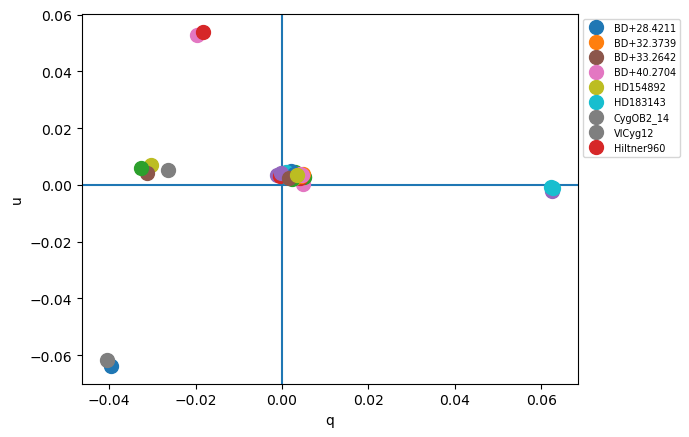

In [79]:
print("All standards")
plt.xlabel("q")
plt.ylabel("u")
plt.errorbar(o1.q.n,o1.u.n,xerr=o1.q.s,yerr=o1.u.s,fmt='.',label=o1.name,markersize=20)
plt.errorbar(o2.q.n,o2.u.n,xerr=o2.q.s,yerr=o2.u.s,fmt='.',label=o2.name,markersize=20)
plt.errorbar(o3.q.n,o3.u.n,xerr=o3.q.s,yerr=o3.u.s,fmt='.',label=o3.name,markersize=20)
plt.errorbar(o4.q.n,o4.u.n,xerr=o4.q.s,yerr=o4.u.s,fmt='.',label=o4.name,markersize=20)
plt.errorbar(o5.q.n,o5.u.n,xerr=o5.q.s,yerr=o5.u.s,fmt='.',label=o5.name,markersize=20)
plt.errorbar(o6.q.n,o6.u.n,xerr=o6.q.s,yerr=o6.u.s,fmt='.',label=o6.name,markersize=20)
plt.errorbar(o7.q.n,o7.u.n,xerr=o7.q.s,yerr=o7.u.s,fmt='.',label=o7.name,markersize=20)
plt.errorbar(o8.q.n,o8.u.n,xerr=o8.q.s,yerr=o8.u.s,fmt='.',label=o8.name,markersize=20)
plt.errorbar(o9.q.n,o9.u.n,xerr=o9.q.s,yerr=o9.u.s,fmt='.',label=o9.name,markersize=20)
plt.errorbar(o10.q.n,o10.u.n,xerr=o10.q.s,yerr=o10.u.s,fmt='.',label=o10.name,markersize=20)
plt.errorbar(o11.q.n,o11.u.n,xerr=o11.q.s,yerr=o11.u.s,fmt='.',label=o11.name,markersize=20)
plt.errorbar(o12.q.n,o12.u.n,xerr=o12.q.s,yerr=o12.u.s,fmt='.',label=o12.name,markersize=20)
plt.errorbar(o13.q.n,o13.u.n,xerr=o13.q.s,yerr=o13.u.s,fmt='.',label=o13.name,markersize=20)
plt.errorbar(o14.q.n,o14.u.n,xerr=o14.q.s,yerr=o14.u.s,fmt='.',label=o14.name,markersize=20)
plt.errorbar(o15.q.n,o15.u.n,xerr=o15.q.s,yerr=o15.u.s,fmt='.',label=o15.name,markersize=20)
plt.errorbar(o16.q.n,o16.u.n,xerr=o16.q.s,yerr=o16.u.s,fmt='.',label=o16.name,markersize=20)
plt.errorbar(o17.q.n,o17.u.n,xerr=o17.q.s,yerr=o17.u.s,fmt='.',label=o17.name,markersize=20)
plt.errorbar(o18.q.n,o18.u.n,xerr=o18.q.s,yerr=o18.u.s,fmt='.',label=o18.name,markersize=20)
plt.errorbar(o19.q.n,o19.u.n,xerr=o19.q.s,yerr=o19.u.s,fmt='.',label=o19.name,markersize=20)
plt.errorbar(o20.q.n,o20.u.n,xerr=o20.q.s,yerr=o20.u.s,fmt='.',label=o20.name,markersize=20)
plt.errorbar(o21.q.n,o21.u.n,xerr=o21.q.s,yerr=o21.u.s,fmt='.',label=o21.name,markersize=20)
plt.errorbar(o22.q.n,o22.u.n,xerr=o22.q.s,yerr=o22.u.s,fmt='.',label=o22.name,markersize=20)
plt.errorbar(o23.q.n,o23.u.n,xerr=o23.q.s,yerr=o23.u.s,fmt='.',label=o23.name,markersize=20)
plt.errorbar(o24.q.n,o24.u.n,xerr=o24.q.s,yerr=o24.u.s,fmt='.',label=o24.name,markersize=20)
plt.errorbar(o25.q.n,o25.u.n,xerr=o25.q.s,yerr=o25.u.s,fmt='.',label=o25.name,markersize=20)
plt.errorbar(o26.q.n,o26.u.n,xerr=o26.q.s,yerr=o26.u.s,fmt='.',label=o26.name,markersize=20)
plt.errorbar(o27.q.n,o27.u.n,xerr=o27.q.s,yerr=o27.u.s,fmt='.',label=o27.name,markersize=20)
plt.errorbar(o28.q.n,o28.u.n,xerr=o28.q.s,yerr=o28.u.s,fmt='.',label=o28.name,markersize=20)
plt.errorbar(o29.q.n,o29.u.n,xerr=o29.q.s,yerr=o29.u.s,fmt='.',label=o29.name,markersize=20)
plt.errorbar(o30.q.n,o30.u.n,xerr=o30.q.s,yerr=o30.u.s,fmt='.',label=o30.name,markersize=20)
plt.errorbar(o31.q.n,o31.u.n,xerr=o31.q.s,yerr=o31.u.s,fmt='.',label=o31.name,markersize=20)
plt.errorbar(o32.q.n,o32.u.n,xerr=o32.q.s,yerr=o32.u.s,fmt='.',label=o32.name,markersize=20)
plt.errorbar(o33.q.n,o33.u.n,xerr=o33.q.s,yerr=o33.u.s,fmt='.',label=o33.name,markersize=20)
plt.errorbar(o34.q.n,o34.u.n,xerr=o34.q.s,yerr=o34.u.s,fmt='.',label=o34.name,markersize=20)
plt.errorbar(o35.q.n,o35.u.n,xerr=o35.q.s,yerr=o35.u.s,fmt='.',label=o35.name,markersize=20)
plt.errorbar(o36.q.n,o36.u.n,xerr=o36.q.s,yerr=o36.u.s,fmt='.',label=o36.name,markersize=20)
plt.errorbar(o37.q.n,o37.u.n,xerr=o37.q.s,yerr=o37.u.s,fmt='.',label=o37.name,markersize=20)
plt.errorbar(o38.q.n,o38.u.n,xerr=o38.q.s,yerr=o38.u.s,fmt='.',label=o38.name,markersize=20)
plt.errorbar(o39.q.n,o39.u.n,xerr=o39.q.s,yerr=o39.u.s,fmt='.',label=o39.name,markersize=20)
plt.errorbar(o40.q.n,o40.u.n,xerr=o40.q.s,yerr=o40.u.s,fmt='.',label=o40.name,markersize=20)
plt.errorbar(o41.q.n,o41.u.n,xerr=o41.q.s,yerr=o41.u.s,fmt='.',label=o41.name,markersize=20)
plt.errorbar(o42.q.n,o42.u.n,xerr=o42.q.s,yerr=o42.u.s,fmt='.',label=o42.name,markersize=20)
plt.errorbar(o43.q.n,o43.u.n,xerr=o43.q.s,yerr=o43.u.s,fmt='.',label=o43.name,markersize=20)
plt.errorbar(o44.q.n,o44.u.n,xerr=o44.q.s,yerr=o44.u.s,fmt='.',label=o44.name,markersize=20)
plt.errorbar(o45.q.n,o45.u.n,xerr=o45.q.s,yerr=o45.u.s,fmt='.',label=o45.name,markersize=20)
plt.errorbar(o46.q.n,o46.u.n,xerr=o46.q.s,yerr=o46.u.s,fmt='.',label=o46.name,markersize=20)
plt.errorbar(o47.q.n,o47.u.n,xerr=o47.q.s,yerr=o47.u.s,fmt='.',label=o47.name,markersize=20)
plt.errorbar(o48.q.n,o48.u.n,xerr=o48.q.s,yerr=o48.u.s,fmt='.',label=o48.name,markersize=20)
plt.errorbar(o49.q.n,o49.u.n,xerr=o49.q.s,yerr=o49.u.s,fmt='.',label=o49.name,markersize=20)
plt.errorbar(o50.q.n,o50.u.n,xerr=o50.q.s,yerr=o50.u.s,fmt='.',label=o50.name,markersize=20)
plt.axvline(0)
plt.axhline(0)

# to make only 1 legend key per star
handles, labels = plt.gca().get_legend_handles_labels()
by_label = OrderedDict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1, 1), fontsize=7)

Zero-p standards
Std of q and u:
0.0015817472389727451 0.0008304061316118361
Instumental q and u are:
0.00247+/-0.00017 0.00332+/-0.00017


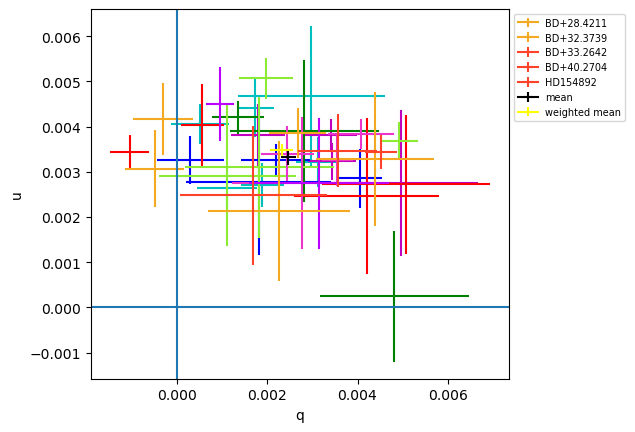

In [80]:
print("Zero-p standards")
plt.xlabel("q")
plt.ylabel("u")

# 2459713
plt.errorbar(o1.q.n,o1.u.n,xerr=o1.q.s,yerr=o1.u.s,c='c',label=o1.name)
plt.errorbar(o2.q.n,o2.u.n,xerr=o2.q.s,yerr=o2.u.s,c='c',label=o2.name)
plt.errorbar(o3.q.n,o3.u.n,xerr=o3.q.s,yerr=o3.u.s,c='c',label=o3.name)
plt.errorbar(o4.q.n,o4.u.n,xerr=o4.q.s,yerr=o4.u.s,c='c',label=o4.name)
plt.errorbar(o5.q.n,o5.u.n,xerr=o5.q.s,yerr=o5.u.s,c='c',label=o5.name)
plt.errorbar(o6.q.n,o6.u.n,xerr=o6.q.s,yerr=o6.u.s,c='c',label=o6.name)

# 2459714
plt.errorbar(o7.q.n,o7.u.n,xerr=o7.q.s,yerr=o7.u.s,c='m',label=o7.name)
plt.errorbar(o8.q.n,o8.u.n,xerr=o8.q.s,yerr=o8.u.s,c='m',label=o8.name)
plt.errorbar(o9.q.n,o9.u.n,xerr=o9.q.s,yerr=o9.u.s,c='m',label=o9.name)
plt.errorbar(o10.q.n,o10.u.n,xerr=o10.q.s,yerr=o10.u.s,c='m',label=o10.name)

# 2459715
plt.errorbar(o11.q.n,o11.u.n,xerr=o11.q.s,yerr=o11.u.s,c='b',label=o11.name)
plt.errorbar(o12.q.n,o12.u.n,xerr=o12.q.s,yerr=o12.u.s,c='b',label=o12.name)
plt.errorbar(o13.q.n,o13.u.n,xerr=o13.q.s,yerr=o13.u.s,c='b',label=o13.name)
plt.errorbar(o14.q.n,o14.u.n,xerr=o14.q.s,yerr=o14.u.s,c='b',label=o14.name)

# 2459716
plt.errorbar(o16.q.n,o16.u.n,xerr=o16.q.s,yerr=o16.u.s,c='g',label=o16.name)
plt.errorbar(o17.q.n,o17.u.n,xerr=o17.q.s,yerr=o17.u.s,c='g',label=o17.name)
plt.errorbar(o18.q.n,o18.u.n,xerr=o18.q.s,yerr=o18.u.s,c='g',label=o18.name)

# 2459717
plt.errorbar(o22.q.n,o22.u.n,xerr=o22.q.s,yerr=o22.u.s,c='r',label=o22.name)
plt.errorbar(o23.q.n,o23.u.n,xerr=o23.q.s,yerr=o23.u.s,c='r',label=o23.name)
plt.errorbar(o24.q.n,o24.u.n,xerr=o24.q.s,yerr=o24.u.s,c='r',label=o24.name)
plt.errorbar(o25.q.n,o25.u.n,xerr=o25.q.s,yerr=o25.u.s,c='r',label=o25.name)

# 2459718
plt.errorbar(o29.q.n,o29.u.n,xerr=o29.q.s,yerr=o29.u.s,c='#8ceb34',label=o29.name)
plt.errorbar(o30.q.n,o30.u.n,xerr=o30.q.s,yerr=o30.u.s,c='#8ceb34',label=o30.name)
plt.errorbar(o31.q.n,o31.u.n,xerr=o31.q.s,yerr=o31.u.s,c='#8ceb34',label=o31.name)
plt.errorbar(o32.q.n,o32.u.n,xerr=o32.q.s,yerr=o32.u.s,c='#8ceb34',label=o32.name)

# 2459722
plt.errorbar(o35.q.n,o35.u.n,xerr=o35.q.s,yerr=o35.u.s,c='#eb34cc',label=o35.name)
plt.errorbar(o36.q.n,o36.u.n,xerr=o36.q.s,yerr=o36.u.s,c='#eb34cc',label=o36.name)
plt.errorbar(o37.q.n,o37.u.n,xerr=o37.q.s,yerr=o37.u.s,c='#eb34cc',label=o37.name)
plt.errorbar(o38.q.n,o38.u.n,xerr=o38.q.s,yerr=o38.u.s,c='#eb34cc',label=o38.name)

# 2459730
plt.errorbar(o39.q.n,o39.u.n,xerr=o39.q.s,yerr=o39.u.s,c='#bb00ff',label=o39.name)
plt.errorbar(o40.q.n,o40.u.n,xerr=o40.q.s,yerr=o40.u.s,c='#bb00ff',label=o40.name)

# 2459731
plt.errorbar(o41.q.n,o41.u.n,xerr=o41.q.s,yerr=o41.u.s,c='#f4a923',label=o41.name)
plt.errorbar(o42.q.n,o42.u.n,xerr=o42.q.s,yerr=o42.u.s,c='#f4a923',label=o42.name)
plt.errorbar(o43.q.n,o43.u.n,xerr=o43.q.s,yerr=o43.u.s,c='#f4a923',label=o43.name)
plt.errorbar(o44.q.n,o44.u.n,xerr=o44.q.s,yerr=o44.u.s,c='#f4a923',label=o44.name)
plt.errorbar(o45.q.n,o45.u.n,xerr=o45.q.s,yerr=o45.u.s,c='#f4a923',label=o45.name)

# 2459732
plt.errorbar(o46.q.n,o46.u.n,xerr=o46.q.s,yerr=o46.u.s,c='#ff432a',label=o46.name)
plt.errorbar(o47.q.n,o47.u.n,xerr=o47.q.s,yerr=o47.u.s,c='#ff432a',label=o47.name)
plt.errorbar(o49.q.n,o49.u.n,xerr=o49.q.s,yerr=o49.u.s,c='#ff432a',label=o49.name)

qs_z = np.array([o1.q,o2.q,o3.q,o4.q,o5.q,o6.q,o7.q,o8.q,o9.q,o10.q,o11.q,
                o12.q,o13.q,o14.q,o16.q,o17.q,o18.q,
                o22.q,o23.q,o24.q,o25.q,o29.q,o30.q,
                o31.q,o32.q,o35.q,o36.q,o37.q,o38.q,
                o39.q,o40.q,o41.q,o42.q,o43.q,o44.q,
                o45.q,o46.q,o47.q,o49.q])
q_z = qs_z.mean()

us_z = np.array([o1.u,o2.u,o3.u,o4.u,o5.u,o6.u,o7.u,o8.u,o9.u,o10.u,o11.u,
                o12.u,o13.u,o14.u,o16.u,o17.u,o18.u,
                o22.u,o23.u,o24.u,o25.u,o29.u,o30.u,
                o31.u,o32.u,o35.u,o36.u,o37.u,o38.u,
                o39.u,o40.u,o41.u,o42.u,o43.u,o44.u,
                o45.u,o46.u,o47.u,o49.u])
u_z = us_z.mean()



All_Q    = [o1.q.n,o2.q.n,o3.q.n,o4.q.n,o5.q.n,o6.q.n,o7.q.n,o8.q.n,o9.q.n,o10.q.n,o11.q.n,
           o12.q.n,o13.q.n,o14.q.n,o16.q.n,o17.q.n,o18.q.n,o22.q.n,o23.q.n,o24.q.n,o25.q.n,
           o29.q.n,o30.q.n,o31.q.n,o32.q.n,o35.q.n,o36.q.n,o37.q.n,o38.q.n,o39.q.n,o40.q.n,
           o41.q.n,o42.q.n,o43.q.n,o44.q.n,o45.q.n,o46.q.n,o47.q.n,o49.q.n]
All_Qerr = [o1.q.s,o2.q.s,o3.q.s,o4.q.s,o5.q.s,o6.q.s,o7.q.s,o8.q.s,o9.q.s,o10.q.s,o11.q.s,
           o12.q.s,o13.q.s,o14.q.s,o16.q.s,o17.q.s,o18.q.s,o22.q.s,o23.q.s,o24.q.s,o25.q.s,
           o29.q.s,o30.q.s,o31.q.s,o32.q.s,o35.q.s,o36.q.s,o37.q.s,o38.q.s,o39.q.s,o40.q.s,
           o41.q.s,o42.q.s,o43.q.s,o44.q.s,o45.q.s,o46.q.s,o47.q.s,o49.q.s]
All_U    = [o1.u.n,o2.u.n,o3.u.n,o4.u.n,o5.u.n,o6.u.n,o7.u.n,o8.u.n,o9.u.n,o10.u.n,o11.u.n,
           o12.u.n,o13.u.n,o14.u.n,o16.u.n,o17.u.n,o18.u.n,o22.u.n,o23.u.n,o24.u.n,o25.u.n,
           o29.u.n,o30.u.n,o31.u.n,o32.u.n,o35.u.n,o36.u.n,o37.u.n,o38.u.n,o39.u.n,o40.u.n,
           o41.u.n,o42.u.n,o43.u.n,o44.u.n,o45.u.n,o46.u.n,o47.u.n,o49.u.n]
All_Uerr = [o1.u.s,o2.u.s,o3.u.s,o4.u.s,o5.u.s,o6.u.s,o7.u.s,o8.u.s,o9.u.s,o10.u.s,o11.u.s,
           o12.u.s,o13.u.s,o14.u.s,o16.u.s,o17.u.s,o18.u.s,o22.u.s,o23.u.s,o24.u.s,o25.u.s,
           o29.u.s,o30.u.s,o31.u.s,o32.u.s,o35.u.s,o36.u.s,o37.u.s,o38.u.s,o39.u.s,o40.u.s,
           o41.u.s,o42.u.s,o43.u.s,o44.u.s,o45.u.s,o46.u.s,o47.u.s,o49.u.s]


q_res = stats.sigma_clipped_stats(All_Q, sigma=2.8) # returns (mean, median, stddev)
q_std_st = q_res[2]
u_res = stats.sigma_clipped_stats(All_U, sigma=2.8) # returns (mean, median, stddev)
u_std_st = u_res[2]

mean_Q = np.average(All_Q,weights=list(map(lambda x: 1.0/x, All_Qerr)))
mean_U = np.average(All_U,weights=list(map(lambda x: 1.0/x, All_Uerr)))
std_Q = np.std(All_Q)/np.sqrt(len(All_Q))
std_U = np.std(All_U)/np.sqrt(len(All_U))

plt.errorbar(q_z.n,u_z.n,xerr=q_z.s,yerr=u_z.s,c='k',label='mean')
plt.errorbar(mean_Q,mean_U,xerr=std_Q,yerr=std_U,c='yellow',label='weighted mean')

# replacing mean estimates by more conservative weighted mean
#q_z = ufloat(mean_Q,std_Q)
#u_z = ufloat(mean_U,std_U)

print("Std of q and u:")
print(np.std(All_Q), np.std(All_U))

print( "Instumental q and u are:")
print( q_z, u_z )

plt.axvline(0)
plt.axhline(0)
plt.gca().set_aspect(1)

# to make only 1 legend key per star
handles, labels = plt.gca().get_legend_handles_labels()
by_label = OrderedDict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1, 1), fontsize=7)

In [81]:
# plot stars separately


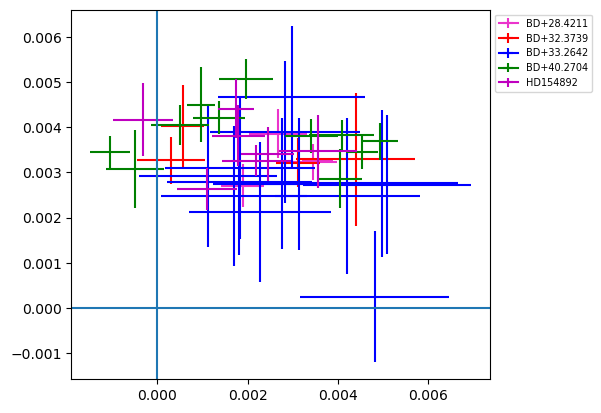

In [82]:
obs = [o1,o2,o3,o4,o5,o6,o7,o8,o9,o10,o11,o12,o13,o14,o15,o16,o17,o18,o19,o20,
      o21,o22,o23,o24,o25,o26,o27,o28,o29,o30,o31,o32,o33,o34,o35,o36,o37,o38,
      o39,o40,o41,o42,o43,o44,o45,o46,o47,o49]

for st in ["BD+28.4211","BD+32.3739","BD+33.2642","BD+40.2704","HD154892"]:
    for i in range(len(obs)):
        if obs[i].name == st:
            if st == "BD+28.4211":
                color = '#eb34cc'
            elif st == "BD+32.3739":
                color = 'r'
            elif st == "BD+33.2642":
                color = 'b'
            elif st == "BD+40.2704":
                color = 'g'
            elif st == "HD154892":
                color = 'm'

            plt.errorbar(obs[i].q.n,obs[i].u.n,xerr=obs[i].q.s,yerr=obs[i].u.s,c=color,label=obs[i].name)
plt.axvline(0)
plt.axhline(0)
plt.gca().set_aspect(1)

# to make only 1 legend key per star
handles, labels = plt.gca().get_legend_handles_labels()
by_label = OrderedDict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1, 1), fontsize=7)

In [83]:
#for o in [o15,o19,o20,o21,o26,o27,o28,o33,o34,o48,o50]:
#    print( o.getPA() )
#    o.correctInst(q_z,u_z)

Now we will find intrumental reference frame rotation with respect to the standad one

In [84]:
# standards EVPA
Hilt960    = ufloat(54.54,0.16)
VICyg = (ufloat(117.0,1.0)+ufloat(116.23,0.14))/2.
CygOB214 = ufloat(86.0,1.0)
HD183143 = (ufloat(179.2,0.2)+ufloat(178.0,1.0))/2.

/run/media/dima/sd1/tmp/ipykernel_15186/2113527337.py:22: FutureWarning: AffineScalarFunc.__lt__() is deprecated. It will be removed in a future release.
  if dPA < -90:


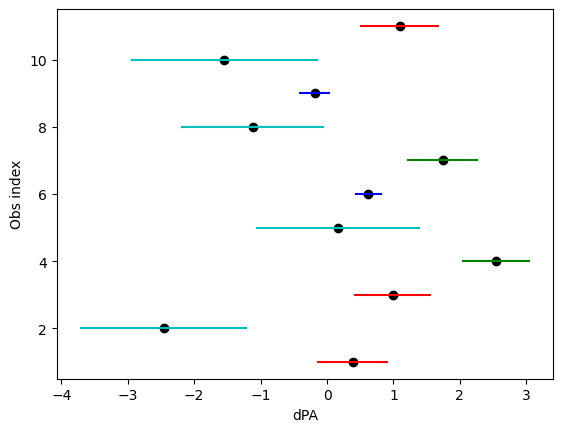

In [85]:
dPAs = []
colors = []
names = []
for o in [o15,o19,o20,o21,o26,o27,o28,o33,o34,o48,o50]:
    if o.name == 'VICyg12':
        dPA = o.getPA() - VICyg
        color = 'g'
        name = 'VICyg12'
    elif o.name == 'Hiltner960':
        dPA = o.getPA() - Hilt960
        color = 'b'
        name = 'Hiltner960'
    elif o.name == 'CygOB2_14':
        dPA = o.getPA() - CygOB214
        color = 'c'
        name = 'CygOB2_14'
    elif o.name == 'HD183143':
        dPA = o.getPA() - HD183143
        color = 'r'
        name = 'HD183143'

    if dPA < -90:
        dPA += 180

    dPAs.append(dPA)
    colors.append(color)
    names.append(name)

plt.xlabel("dPA")
plt.ylabel("Obs index")

for i,dPA in enumerate(dPAs):
    plt.plot(dPA.n,i+1,'ko')
    plt.errorbar(dPA.n,i+1,xerr=dPA.s,yerr=0,c=colors[i],label=names[i])


In [86]:
dPA = np.array([dPAs[1],dPAs[3],dPAs[4],dPAs[5],dPAs[6],dPAs[7],dPAs[8],dPAs[9]]).mean()
print('Instument rotations is ',dPA,' degrees')

Instument rotations is  -0.0+/-0.6  degrees


Now we will correct Mark stars for the instumental polarization and rotate the reference frame by the opposite angle

In [87]:
Mark = [s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21]
for o in Mark:
    #o.correctInst(q_z,u_z)
    QmodelPrediction = func(o.x, o.y, *fittedParametersQ[0]) # the second element in fittedParametersQ, fittedParametersU
    UmodelPrediction = func(o.x, o.y, *fittedParametersU[0]) # is covariance we don't need it
    o.q = o.q - ufloat(QmodelPrediction, q_std_st)
    o.u = o.u - ufloat(UmodelPrediction, u_std_st)
    o.correctRot(-dPA)

In [88]:
fout = open('Mark_inst_corr.dat','w')
fout.write("#JD PD[%] sPD EPVA[deg] sEVPA q sq u su\n")
for o in Mark:
    out_str = "{:10.5f}".format(o.JD) + "  "
    out_str += "{:7.2f}".format(round(o.getP().n*100, 2))
    out_str += "{:7.2f}".format(round(o.getP().s*100, 2))
    out_str += "{:8.2f}".format(round(o.getPA().n, 2))
    out_str += "{:8.2f}".format(round(o.getPA().s, 2))
    out_str += "{:9.5f}".format(round(o.q.n, 5))
    out_str += "{:9.5f}".format(round(o.q.s, 5))
    out_str += "{:9.5f}".format(round(o.u.n, 5))
    out_str += "{:9.5f}".format(round(o.u.s, 5))
    out_str += "\n"
    fout.write(out_str)
fout.close()